4000 50


/share/home2/ebrahimis/project1_3_8/venv/lib/python3.8/site-packages/torch/nn/functional.py:1340: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/sac-lstm/radio_calc.py:397: RuntimeWarning: divide by zero encountered in log10
  self.signal_strength_dB[u] = 10 * np.log10(self.signal_strength)
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/sac-lstm/radio_calc.py:401: RuntimeWarning: divide by zero encountered in log10
  self.SINR_dB[u] = 10 * np.log10(self.SINR)
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/sac-lstm/radio_calc.py:395: RuntimeWarning: divide by zero encountered in log10
  self.interference_dB[u] = 10 * np.log10(I_inter)


Total Handovers  over all timesteps: Episode 0= 17 HOs
Total Handovers  over all timesteps: Episode 100= 15 HOs
Total Handovers  over all timesteps: Episode 200= 10 HOs
Total Handovers  over all timesteps: Episode 300= 12 HOs
Total Handovers  over all timesteps: Episode 400= 14 HOs
Total Handovers  over all timesteps: Episode 500= 12 HOs
Total Handovers  over all timesteps: Episode 600= 16 HOs
Total Handovers  over all timesteps: Episode 700= 11 HOs
Total Handovers  over all timesteps: Episode 800= 14 HOs
Total Handovers  over all timesteps: Episode 900= 11 HOs
Total Handovers  over all timesteps: Episode 1000= 15 HOs
Total Handovers  over all timesteps: Episode 1100= 10 HOs
Total Handovers  over all timesteps: Episode 1200= 14 HOs
Total Handovers  over all timesteps: Episode 1300= 17 HOs
Total Handovers  over all timesteps: Episode 1400= 19 HOs
Total Handovers  over all timesteps: Episode 1500= 9 HOs
Total Handovers  over all timesteps: Episode 1600= 31 HOs
Total Handovers  over all t

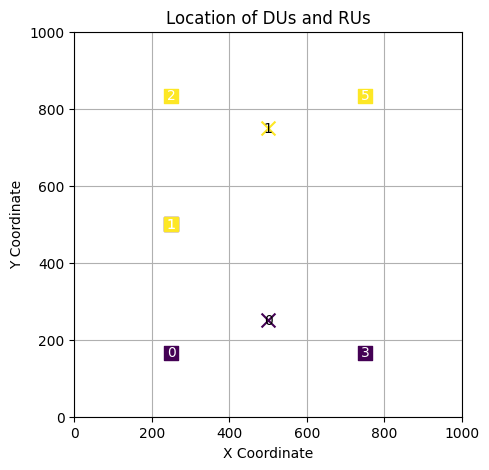

-------------
Runtime Duration:
-------------



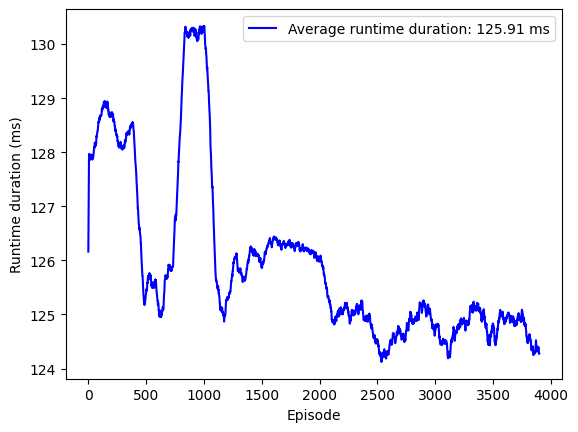

-------------
Avg PRBs used per user for SAC algorithm:
-------------



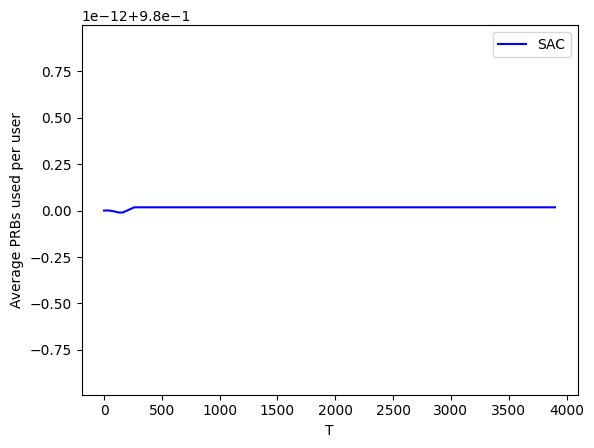

-------------
Jain's fairness index for PRB allocation:
-------------



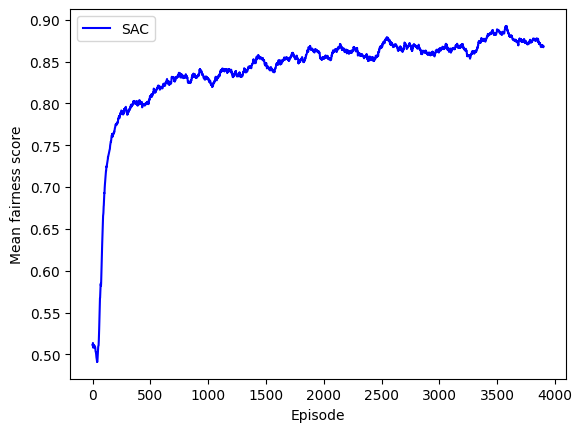

-------------
Mean episodic rewards:
-------------



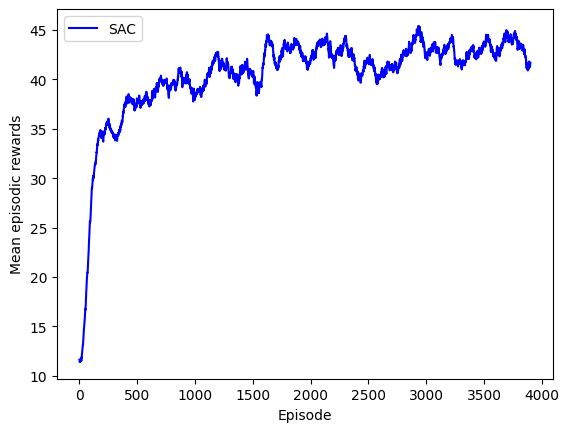

-------------
Constraint Satisfaction:
-------------



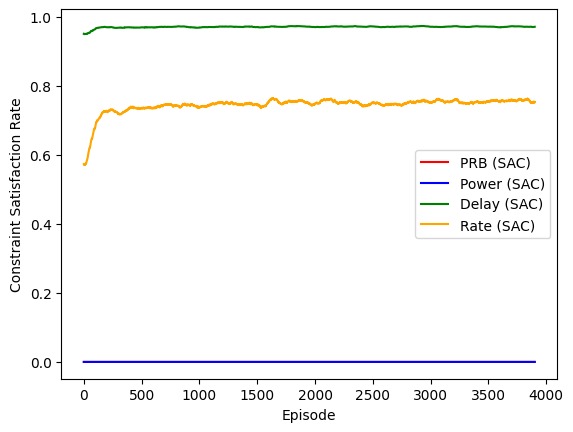

-------------
SSL Metrics:
-------------



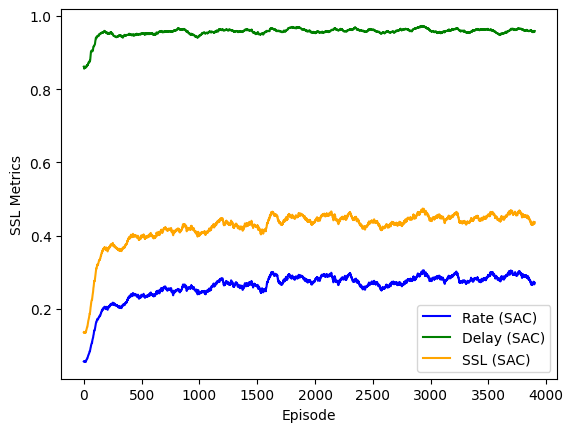

-------------
Comparison of Average E2E Delay (SAC):
-------------



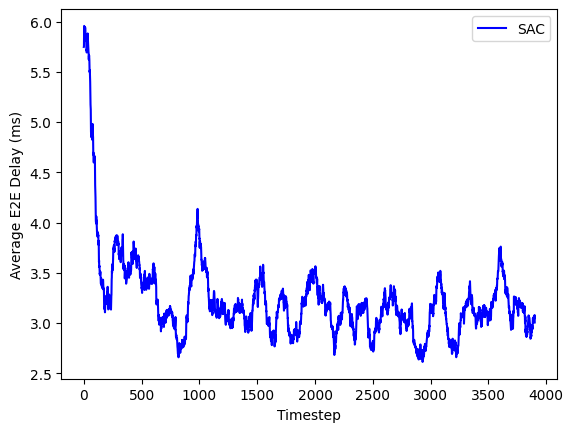

-------------
Average Data Rate (SAC):
-------------



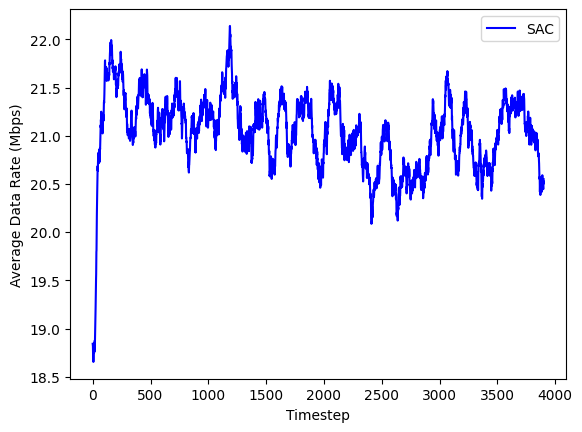

-------------
Average of total allocated power to each user (SAC):
-------------



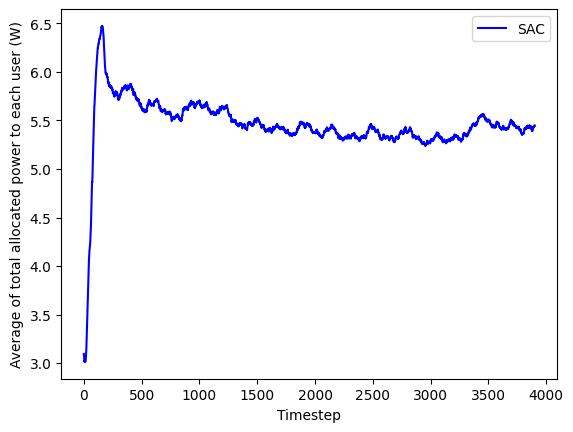

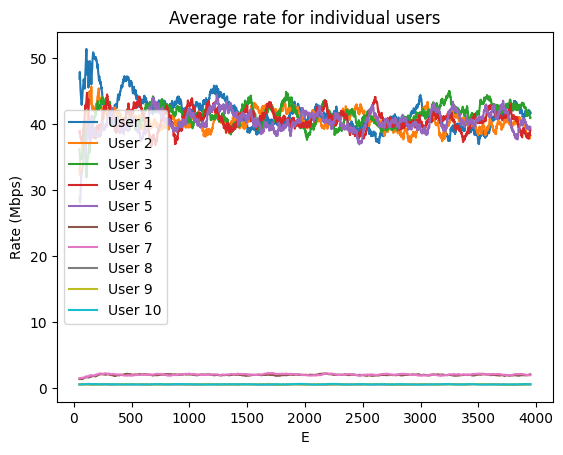

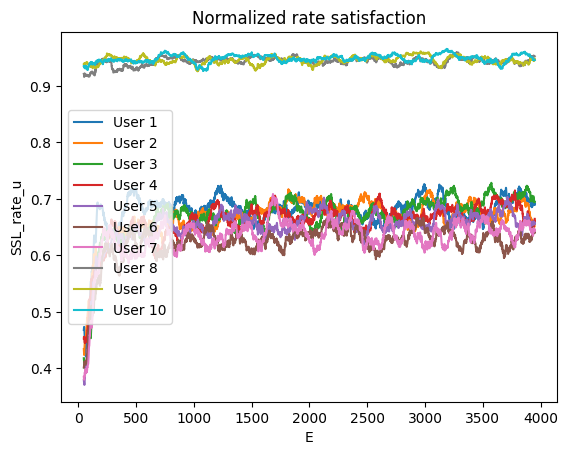

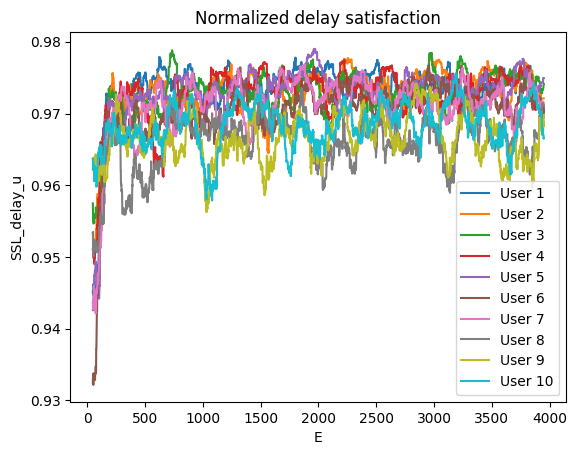

-------------
Sum of handovers (each episode):
-------------



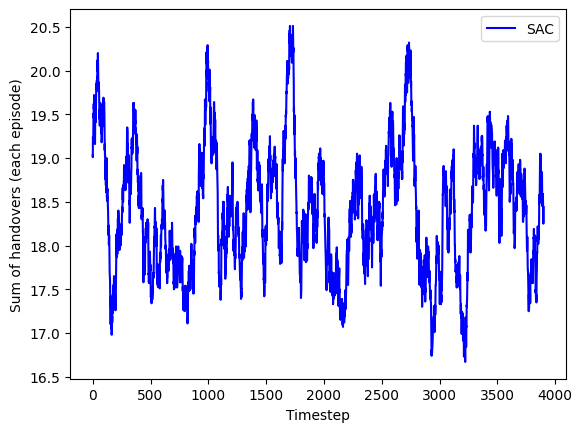

-------------
Average No. of handovers per user:
-------------



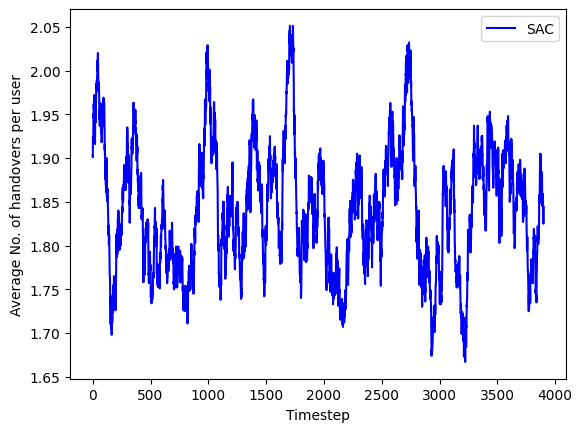

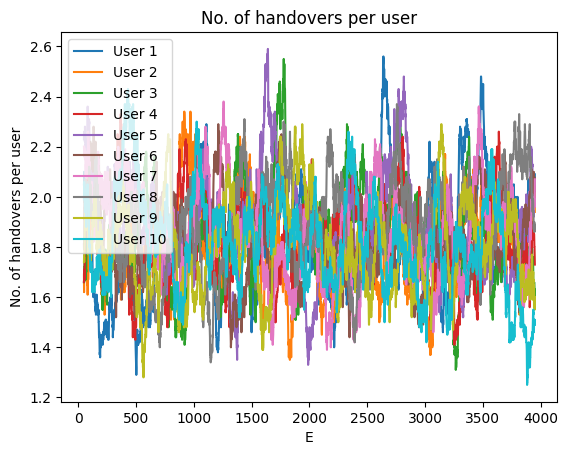

Total time for 50 timesteps (10 users) in 4000 Episdoes (aka iterations or epochs): 6.0 hours 59.0 minutes 41.935789585113525 seconds


In [1]:
%run "r-main_constraint-based.py"

In [ ]:
 def __init__(self, alpha, beta, n_actions, input_dims, tau = 0.005,
            layer1_size = 500, layer2_size = 256, batch_size = 256, reward_scale = 0.2): #input_dims (state size)
        self.gamma = 0.99 # 99 #0.8 # 0.5 to 0.8###if it is near 1, it'd be very dependent to the past; therefore, not very adaptable to changes #0.8 ####CHANGE TO 0.8 # 0.99 #0.8 in the TNSM22 paper # was 0.7 in orig code
        self.tau = tau # tau # 0.001 in the paper #was 0.5 in orig code
        self.pointer = 0
        self.max_size = 200000 
# config.yaml lstm
USER_NO: 10 #10 #20 # 4
BW: 180000  # %  180 kHz  (to be updated after consulting with Faouzi)
PRB_NO: 100 #  (to be updated after consulting with Faouzi)
SIGMA_NOISE: 10**(-17.4) #3.981e-18 # # = -174 dBm <tnsm23nouruzi> #
ETA_AREA: 3 # for rural areas according to TS 38.215 (Used in the Rayleigh/Distance formula for calculating data rate (Shannon)); equal to 3 for rural; 4 for urban areas # check also 38.913 for mobility scenarios and classes
X_LIM: 1000
Y_LIM: 1000
#CU_NO: 1 # only 1 CU is envisioned. It is co-located with the Near-RT RIC
DU_NO: 2 # all connected to the CU
RU_PER_DU_NO: 3 # Each DU has 4 RUs; Total number of RUs = 4*2 = 8
#BS_NO: 20 # should be equal to RU_PER_DU_NO*DU_NO # static for now; Location.bs_location() --- now it is bound to 4 BSs. Can be changed later
FH_BW_CAPACITY: 5000 # 100 Mbps in twc23kavehmadani# Mbps (5 Gbps) (link between RU and its DU) #
E2_BW_CAPACITY: 100000 # 5 Gbps in twc23kavehmadani #Mbps (100 Gbps) (link between DU and Near-RT RIC (equal to F1, which is between DU and CU))
#VM_NO: 9 # 6
#VNF_NO: 5 # 5
#NODE_NO: 12
SLICE_NO: 3 #5 # number of slice types ; will be indexed from 0 to (SLICE_NO - 1)
MAX_POWER: 40 # in watts ; equals to 46 dBm <tvt23choi> # 12 # (to be updated after consulting with Faouzi) # 46 dBm in tvt23choi = 40 watts (Much higher than normal papers)
OMEGA_1: 0.5 # to use in SSL weighting (for data rate term)
VELOCITY: 10 #0 #-1 means random #35 # m/s [5,20,35,50] #             = self.V ##################################################
CONST_D_MAX: -1 # 20 #-1 # ms
CONST_R_MIN: -1 # 5 #-1 # Mbps  
#ISOLATION_ORDER: -1
PACKET_SIZE: -1 # 0.012 # based on 1500 bytes for eMBB # in mbits # -1 # twc23kavehmadani: 1 KB for URLLC and 125 KB for eMBB
#PACKET_NO: 830  # 500 # -1 # packet generation rate per second # 0.012*500 = 6 Mbps # 0.012*830 = 9.96 Mbps
RAYLEIGH_SCALE: 1 # sigma in Rayleigh formula
#Episodes (T) and Number of monte-carlo runs:#
E: 4000 #1000# episodes/epochs for learning (the loop before T loop (replaces MC loop))
T: 50 #100# 14000 # 1000  # Number of timeslots
#MC: 3  # Number of Monte-carlo runs
#Hyperparameters for the DRL algorithm
ALPHA_ACT: 0.0001 # 0.00001 # 0.00001 #0.000001 # actor's learning rate
BETA_ACT: 0.0001 # 0.00005 # 0.00005 # 0.000005 # Critic's learning rate
VAR: 1
DECAY_VAR: 0.9994 #95 #95 # .995 # can determine the ratio of exploration to exploitation
PSI: 0.5 # for putting two last actions in states